In [1]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.0/96.0 kB 4.5 MB/s eta 0:00:00


In [2]:
import yaml
import os
from google.colab import drive
from ultralytics import YOLO
import sys
import requests
import cv2

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


In [3]:
drive.mount('/content/drive')

Mounted at /content/drive


#1. Import model

In [31]:
MODEL_PATH= r"/content/drive/MyDrive/PROJECTS/BEE-SYSTEMS-PROJECT/MODELS/bee_wasp_detection/yolo26s_img640_baseline_v1-nano/weights/best.pt"
# kiểm tra đường dẫn
if os.path.exists(MODEL_PATH):
    print(f"[PASS] {MODEL_PATH}")
else:
    print(f"[ERROR] {MODEL_PATH}")
    sys.exit("Dừng chương trình do không tìm thấy file model.")


model = YOLO(MODEL_PATH)
print("Import model complete")

[PASS] /content/drive/MyDrive/PROJECTS/BEE-SYSTEMS-PROJECT/MODELS/bee_wasp_detection/yolo26s_img640_baseline_v1-nano/weights/best.pt
Import model complete


#2. Kiểm tra dữ liệu ảnh


[INFO] Không sử dụng Path ảnh.
Bạn có muốn thực hiện chạy nhận diện không? (Y/N): Y
[RUN] Đang xử lý ảnh từ Link URL: https://www.bensbees.com.au/wp-content/uploads/2016/04/difference-between-bee-wasp.jpg.webp

image 1/1 /content/difference-between-bee-wasp.jpg.webp: 352x640 1 bee, 1 hornet, 649.2ms
Speed: 16.4ms preprocess, 649.2ms inference, 35.6ms postprocess per image at shape (1, 3, 352, 640)
[SUCCESS] Đã xử lý xong. Đang hiển thị kết quả...


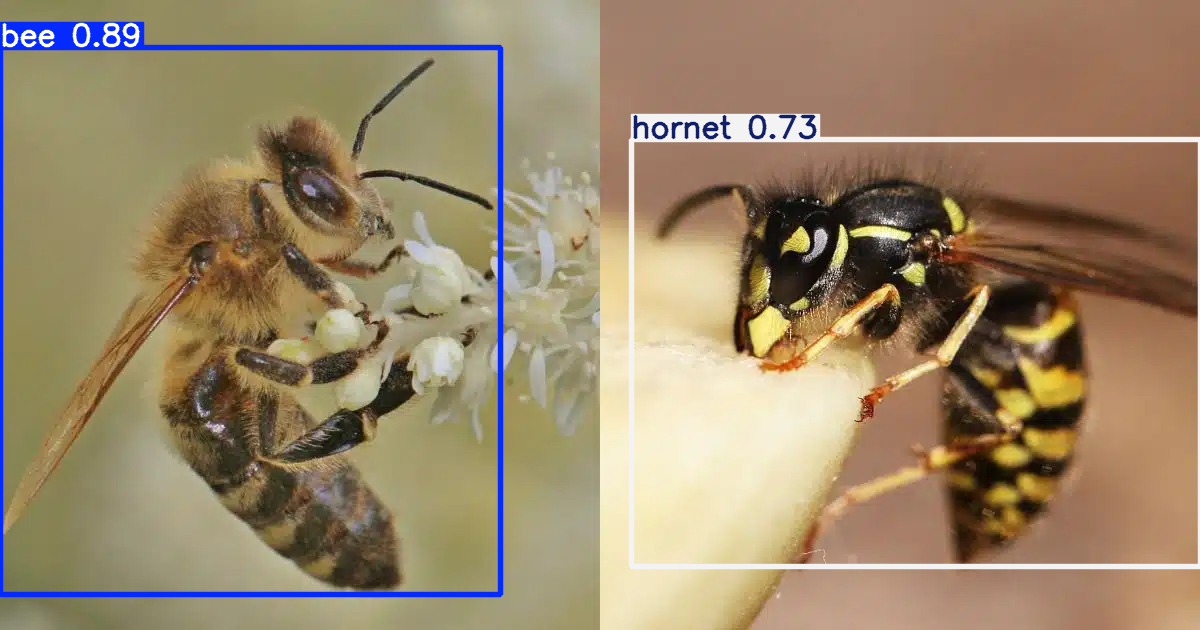

In [5]:
from os.path import exists
# --- CẤU HÌNH ĐẦU VÀO ---
# Nhập link ảnh trên internet (để trống nếu dùng path ảnh local)
# IMAGE_URL = "https://cdn.shopify.com/s/files/1/0279/7132/1908/files/195222037_l_normal_none_480x480.jpg?v=1679328152"
IMAGE_URL="https://www.bensbees.com.au/wp-content/uploads/2016/04/difference-between-bee-wasp.jpg.webp"
# Nhập path ảnh từ thiết bị/Colab (để trống nếu dùng link ảnh)
IMAGE_PATH = ""


# --- 1. KIỂM TRA LINK ẢNH ---
is_url_valid = False
if IMAGE_URL and IMAGE_URL.strip():
    try:
        # gửi request kiểm tra xem link có tồn tại và tải được hay không
        response = requests.head(IMAGE_URL, timeout= 5)
        if response.status_code == 200:
            is_url_valid = True
        else:
          print(f"[WARN] Link ảnh trả về mã lỗi: {response.status_code}")
    except requests.RequestException:
            print(f"[WARN] Không thể kết nối đến Link ảnh: {IMAGE_URL}")
else:
    print("[INFO] Không sử dụng Link ảnh.")


# --- 2. KIỂM TRA PATH ẢNH ---
is_path_vaild = False
if IMAGE_PATH and IMAGE_PATH.strip():
    if os.path.exists(IMAGE_PATH):
        print(f"[PASS] File ảnh tồn tại: {IMAGE_PATH}")
        is_path_valid = True
    else:
        print(f"[WARN] Không tìm thấy file ảnh tại: {IMAGE_PATH}")
else:
    print("[INFO] Không sử dụng Path ảnh.")


# --- 3. XÁC THỰC CHẠY CHƯƠNG TRÌNH Y/N ---
confirm = input("Bạn có muốn thực hiện chạy nhận diện không? (Y/N): ").strip().upper()
if confirm != 'Y':
    print("[STOP] Đã hủy bỏ thực hiện theo yêu cầu người dùng.")
    sys.exit()




# --- 4. THỰC HIỆN LỆNH ---
# Kiểm tra nếu có ít nhất 1 trong 2 đầu vào hợp lệ
if not is_url_valid and not is_path_valid:
    print("[ERROR] Không có nguồn ảnh nào hợp lệ (cả Link và Path đều lỗi hoặc trống)!")
    sys.exit()



results = None
# thực hiện kiểm tra modol bằng path ảnh
if is_path_vaild:
    print(f"[RUN] Đang xử lý ảnh từ Path: {IMAGE_PATH}")
    results = model(IMAGE_PATH)

# Thực hiện kiểm tra Model bằng Link ảnh (Nếu không có path ảnh hợp lệ nhưng link hợp lệ)
elif is_url_valid:
    print(f"[RUN] Đang xử lý ảnh từ Link URL: {IMAGE_URL}")
    results = model(IMAGE_URL)

else:
    print("[ERROR] Không có nguồn ảnh nào hợp lệ (cả Link và Path đều lỗi hoặc trống)!")
    sys.exit()


# --- 5. SHOW ĐẦU RA ---
if results:
    print("[SUCCESS] Đã xử lý xong. Đang hiển thị kết quả...")
    # Hiển thị ảnh kết quả trực tiếp trên Colab
    for r in results:
        r.show()

#3. Kiểm tra dữ liệu video

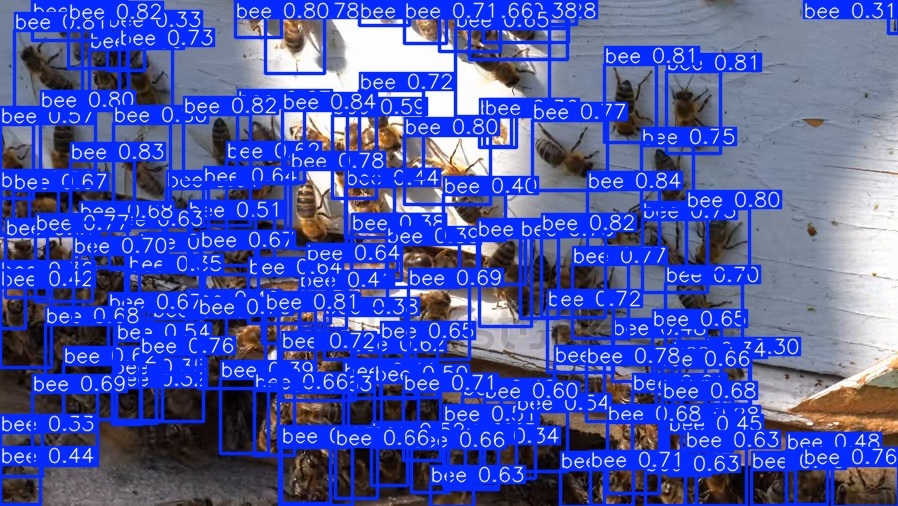

KeyboardInterrupt: 

In [32]:
import cv2
from IPython.display import display, Image, clear_output

# Nhập URL online hoặc đường dẫn file local trên Colab
VIDEO_SOURCE = "https://www.shutterstock.com/shutterstock/videos/3976973929/preview/stock-footage-close-up-of-honeybees-warming-in-sun-on-their-beehive-beekeeping-process-honey-productio-and.webm"
# VIDEO_SOURCE = "/content/sample_video.mp4"

# stream=True giúp yield từng frame để hiển thị ngay, không bị tràn RAM
results = model.predict(source=VIDEO_SOURCE, save=False, stream=True)

for r in results:
    # 1. Lấy frame đã vẽ sẵn bounding box & nhãn
    annotated_frame = r.plot()

    # 2. Encode frame sang định dạng ảnh JPEG
    _, buffer = cv2.imencode('.jpg', annotated_frame)

    # 3. Xóa output cũ và hiển thị frame mới (tạo hiệu ứng phát video)
    clear_output(wait=True)
    display(Image(data=buffer.tobytes()))

In [ ]:
# VSCODE version
VIDEO_PATH = "sample_video.mp4"

# Đọc video từng frame bằng OpenCV
cap = cv2.VideoCapture(VIDEO_PATH)

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # Dự đoán frame
    results = model(frame)

    # Lấy frame đã vẽ sẵn bounding box
    annotated_frame = results[0].plot()

    # Hiển thị lên màn hình
    cv2.imshow("YOLO Detection", annotated_frame)

    # Nhấn 'q' trên bàn phím để dừng video
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()